In [6]:
# testing the new recomp functions

import numpy as np
from scipy.stats import uniform_direction
import sys, os
from SpaceBalls.radiation_settings import radiation_settings_from_EEI_truth_name
from SpaceBalls.postproc_EEI_estimation import get_acc_to_flux_factor, get_true_EEI_time_series, estimate_EEI_avg #, get_all_orbital_sma_0, get_stacked_avg_maps_3D_mode
from SpaceBalls.radiation_fluxes_preprocessing import compute_a_hist_at_sat_r_hist, compute_F_hist_at_sat_r_hist, F_vec_to_Fr, get_norm_across_last_dim, get_EEI_truth_daily_jd_arrays, get_mid_day_jd_array, get_toa_grid_from_rad_config
from SpaceBalls.utils import normal_smoother, progress_bar, nanrms, get_Rotation

import SpaceBalls.input_database_manager as input_manager
from SpaceBalls.sph_meshing import get_faceted_sphere_mesh, QuadratureGrid, KnockeGridMONTE, RegularLatLonGrid
from SpaceBalls.plotter import Plotter
import SpaceBalls.constants as constants
import itertools
import time
import random
from SpaceBalls.paths import CONFIG_DIR, MEDIA_DIR, INPUT_DIR, OUTPUT_DIR
LIGHT_SPEED = constants.light_speed()

def get_random_vectors(n):
    return uniform_direction.rvs(dim=3, size=n)


def get_avg_cross_sectional_area(normal_vecs, areas):

    all_areas = []
    all_s = -get_random_vectors(10000)

    for i, s in enumerate(all_s):
        total_A = 0
        for i, (n, area) in enumerate(zip(normal_vecs, areas)):
            cos = np.max([0, np.dot(-s, n)])
            total_A += area * cos
        #print(f"cos gamma: {cos}")

        all_areas.append(total_A)
    
    return np.mean(all_areas)

desired_sb = {
    'force_settings': 2,
    'integration_settings': 110,  # 0 for GRACE-FO_orbit
    'orbit_name': 'Ajisai_orbit', # 'GRACE-FO_orbit', # 'LAGEOS_orbit', #'GRACE-FO_orbit',
    'delta_t_out': 15,
}

keys = input_manager.get_primary_keys(desired_sb)
#keys = [key for key in keys if 'LAGEOS' not in key]
assert(len(keys)==1)
sb_tag = keys[0]

sb_tag = 'SB_R800_21'  # 'GRACE-FO_spherical' # 'LAGEOS_119' # 'SB_R800_3'

#EEI_truth = input_manager.get_dicts(sb_tag)['force_settings']['EEI_truth']
EEI_truth = 'EEI_truth_35' # + str(EEI_truth)
#grid = get_toa_grid_from_rad_config(radiation_settings_from_EEI_truth_name(EEI_truth))
grid = get_toa_grid_from_rad_config(radiation_settings_from_EEI_truth_name(EEI_truth), 
                                    quadrature_order=131)

n_days = 1
start_idx = 10
day_idxs = range(start_idx, start_idx+n_days)
all_jd = [None] * n_days
all_erp = [None] * n_days
all_erp_recomp_plated = [None] * n_days
all_erp_recomp_cannonball = [None] * n_days
all_srp = [None] * n_days
all_srp_recomp_plated = [None] * n_days
all_srp_recomp_cannonball = [None] * n_days

sb_og_dict = input_manager.get_dicts(sb_tag)
mass = sb_og_dict['sc_params']['mass']
area = sb_og_dict['sc_params']['area']
sat_radius = np.sqrt(area/np.pi)

def compute_a_plated_vs_cannonball(sat_dict, spin_f):

    avg_ca_SW = np.sum(sat_dict['plate_ca_SW']*sat_dict['plate_areas']) / np.sum(sat_dict['plate_areas'])
    avg_cd_SW = np.sum(sat_dict['plate_cd_SW']*sat_dict['plate_areas']) / np.sum(sat_dict['plate_areas'])
    avg_cs_SW = np.sum(sat_dict['plate_cs_SW']*sat_dict['plate_areas']) / np.sum(sat_dict['plate_areas'])
    # true_avg_area = get_avg_cross_sectional_area(sat_dict['plate_normals'], sat_dict['plate_areas'])
    true_avg_area = np.sum(sat_dict['plate_areas']) / 4

    F_to_a = true_avg_area / sat_dict['mass'] * (avg_ca_SW + avg_cs_SW + 13*avg_cd_SW/9) / LIGHT_SPEED
    F_to_a_monte = 1/get_acc_to_flux_factor(sb_tag)

    # spin_f = 0.015 # [Hz]
    spin_w = 2 * np.pi * spin_f
    theta_0 = 0

    for i, day_idx in enumerate(day_idxs):

        r_hist_day = np.load(os.path.join(OUTPUT_DIR, sb_tag, 'day_'+str(day_idx), 'xyz_ecef.npy'))
        u_hist_day = r_hist_day/get_norm_across_last_dim(r_hist_day)[...,None]
        jd_hist_day = np.load(os.path.join(OUTPUT_DIR, sb_tag, 'day_'+str(day_idx), 'jd_vec.npy'))
        all_jd[i] = jd_hist_day

        erp_ar_hist = np.load(os.path.join(OUTPUT_DIR, sb_tag, 'day_'+str(day_idx), 'erp.npy'))[:,0] * 1e3
        all_erp[i] = erp_ar_hist

        srp_ar_hist = np.load(os.path.join(OUTPUT_DIR, sb_tag, 'day_'+str(day_idx), 'srp.npy'))[:,0] * 1e3
        all_srp[i] = srp_ar_hist

        # rotation axis in the direction of the orbit angular momentum
        v_hist_day = np.load(os.path.join(OUTPUT_DIR, sb_tag, 'day_'+str(day_idx), 'vxvyvz_ecef.npy'))
        h_hist_day = np.cross(r_hist_day, v_hist_day, axis=1)
        rot_axis_hist = h_hist_day / get_norm_across_last_dim(h_hist_day)[:,None]

        theta = theta_0 + spin_w * (jd_hist_day - jd_hist_day[0]) * (24*3600)
        sat_R_body2ECEF_hist = get_Rotation(rot_axis=rot_axis_hist.T, theta_hist=theta).as_matrix()

        erp_a_hist, srp_a_hist = compute_a_hist_at_sat_r_hist(EEI_truth, 
                                                            sat_dict,
                                                            r_hist_day, 
                                                            jd_hist_day, 
                                                            toa_grid=grid,
                                                            sat_R_body2ECEF_hist=sat_R_body2ECEF_hist)
        all_erp_recomp_plated[i] = -np.squeeze(F_vec_to_Fr(erp_a_hist, u_hist_day[None,...]))
        all_srp_recomp_plated[i] = -np.squeeze(F_vec_to_Fr(srp_a_hist, u_hist_day[None,...]))

        a+3
        erp_F_hist, srp_F_hist = compute_F_hist_at_sat_r_hist(EEI_truth, #'EEI_truth_1', 
                                                        r_hist_day, 
                                                        jd_hist_day, 
                                                        toa_grid=grid,
                                                        erp_wl_split=False)
        all_erp_recomp_cannonball[i] = -F_to_a * np.squeeze(F_vec_to_Fr(erp_F_hist, u_hist_day[None,...]))
        all_srp_recomp_cannonball[i] = -F_to_a * np.squeeze(F_vec_to_Fr(srp_F_hist, u_hist_day[None,...]))

        theta_0 = theta[-1] + np.mean(np.diff(theta)) # add slight dt to the start of next day

    erp_cannonball = np.concatenate(all_erp_recomp_cannonball)
    srp_cannonball = np.concatenate(all_srp_recomp_cannonball)
    erp_plated = np.concatenate(all_erp_recomp_plated)
    srp_plated = np.concatenate(all_srp_recomp_plated)

    net_cannonball = erp_cannonball + srp_cannonball
    net_plated = erp_plated + srp_plated

    return net_cannonball, net_plated


r vectors projected to ellipsoid


In [ ]:
# the following block is just to compute ERP and SRP computation times
n_faces = 600
spin_f = 0.1

mesh = get_faceted_sphere_mesh(sat_radius, n_faces, default_golden=False)
vertices, centroids, normal_vecs, areas, edge_conns, hull = mesh

ca_SW = 0.12
cd_SW = 0.2
cs_SW = 0.68
sat_dict = {'mass': mass,
            'coeff_wl_split': False,
            'plate_normals': normal_vecs,
            'plate_areas': areas,
            'plate_ca_SW': ca_SW * np.ones(n_faces),
            'plate_cd_SW': cd_SW * np.ones(n_faces),
            'plate_cs_SW': cs_SW * np.ones(n_faces)
            }

net_cannonball, net_plated = compute_a_plated_vs_cannonball(sat_dict, spin_f)

n_vertices: 302
Number of faces: 600
Time SRP 1: 0.0005135536193847656
Splitting day into 1 chunks
Computing chunk 1/1...
Getting smooth daily ae hist...
Computing flux...
Getting ADMs...
Computing integral with einsum...
Time ERP 1: 2.9192585945129395
Time ERP 2: 2.1843998432159424
Time SRP 2: 0.004149436950683594


NameError: name 'a' is not defined

SPIN FREQ.: 0 HZ
Number of faces: 24
Splitting day into 1 chunks
Computing chunk 1/1...
Getting smooth daily ae hist...
Computing flux...
Getting ADMs...
Computing integral with einsum...
Splitting day into 1 chunks
Computing chunk 1/1...
Getting smooth daily ae hist...
Computing flux...
Getting ADMs...
Computing integral with einsum...
Splitting day into 1 chunks
Computing chunk 1/1...
Getting smooth daily ae hist...
Computing flux...
Getting ADMs...
Computing integral with einsum...
Splitting day into 1 chunks
Computing chunk 1/1...
Getting smooth daily ae hist...
Computing flux...
Getting ADMs...
Computing integral with einsum...
Number of faces: 48
Splitting day into 1 chunks
Computing chunk 1/1...
Getting smooth daily ae hist...
Computing flux...
Getting ADMs...
Computing integral with einsum...


KeyboardInterrupt: 

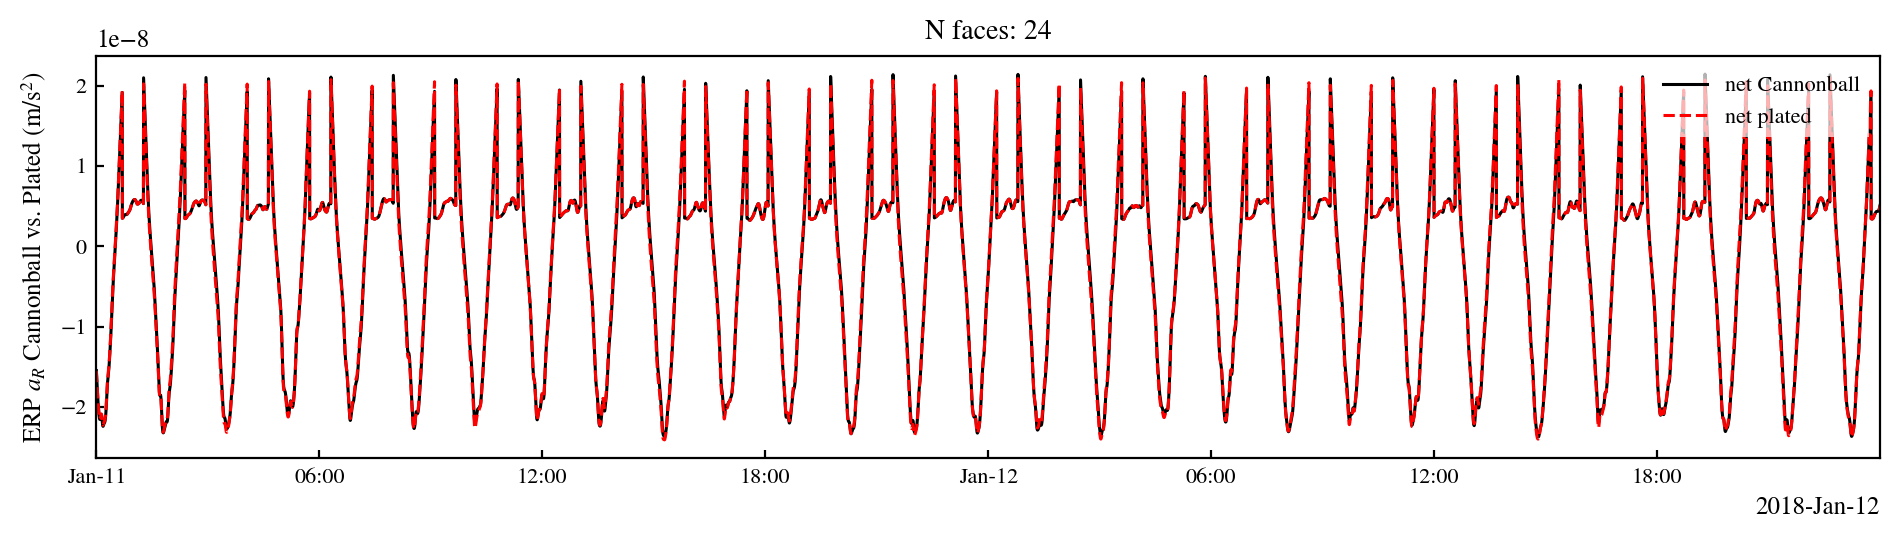

In [7]:

n_faces_array = [24, 48,72, 96, 120, 250, 500]
#spin_f_array = np.linspace(0, 0.05, 15) #[0, 0.05, 0.015, 0.03] # = 0.015 # [Hz]
spin_f_array = [0]

all_bias = np.zeros((len(spin_f_array), len(n_faces_array)))
all_rms = np.zeros((len(spin_f_array), len(n_faces_array)))

for i, spin_f in enumerate(spin_f_array):
    print(f"SPIN FREQ.: {spin_f} HZ")
    all_net_diffs = {}
    all_net_diffs_smooth = {}
    all_net_cannonball = {}
    all_net_plated = {}

    for j, n_faces in enumerate(n_faces_array):
        mesh = get_faceted_sphere_mesh(sat_radius, n_faces, default_golden=False)
        vertices, centroids, normal_vecs, areas, edge_conns, hull = mesh

        ca_SW = 0.12
        cd_SW = 0.2
        cs_SW = 0.68
        sat_dict = {'mass': mass,
                    'coeff_wl_split': False,
                    'plate_normals': normal_vecs,
                    'plate_areas': areas,
                    'plate_ca_SW': ca_SW * np.ones(n_faces),
                    'plate_cd_SW': cd_SW * np.ones(n_faces),
                    'plate_cs_SW': cs_SW * np.ones(n_faces)
                    }

        net_cannonball, net_plated = compute_a_plated_vs_cannonball(sat_dict, spin_f)
        all_net_cannonball[f"plated {n_faces} faces"] = net_cannonball
        all_net_plated[f"plated {n_faces} faces"] = net_plated

        net_diff = net_cannonball-net_plated
        net_diff_smooth = normal_smoother(net_diff, np.concatenate(all_jd), 1, out_length_mode='same_with_nans')
        all_net_diffs[f"plated {n_faces} faces"] = net_diff
        all_net_diffs_smooth[f"plated {n_faces} faces"] = net_diff_smooth

        all_bias[i,j] = np.mean(net_diff)
        all_rms[i,j] = nanrms(net_diff)

        Plotter.plot_time_series(np.concatenate(all_jd), 
                            {'net Cannonball': net_cannonball,
                             'net plated': net_plated},
                            ylabel='ERP $a_R$ Cannonball vs. Plated (m/s$^2$)',
                            f_width=2.4, f_height=0.7,
                            title=f"N faces: {n_faces}", col_array=['k', 'r'])

    Plotter.plot_time_series(np.concatenate(all_jd), 
                            all_net_diffs,
                            ylabel='ERP $a_R$ Cannonball vs. Plated (m/s$^2$)',
                            f_width=2.4, f_height=0.7,
                            title=f"Spin f: {spin_f} Hz")
    
    Plotter.plot_time_series(np.concatenate(all_jd), 
                            all_net_diffs,
                            ylabel='ERP $a_R$ Cannonball vs. Plated (m/s$^2$)',
                            f_width=2.4, f_height=0.7,
                            title=f"Spin f: {spin_f} Hz")
    
    Plotter.plot_time_series(np.concatenate(all_jd), 
                            all_net_diffs_smooth,
                            ylabel='ERP $a_R$ Cannonball vs. Plated (m/s$^2$)',
                            f_width=2.4, f_height=0.6,
                            title=f"Spin f: {spin_f} Hz")


### Bias and RMS versus plate count and spin frequency

Run the sweep above first. These four figures reuse `all_bias` and `all_rms` without recomputing accelerations. Here $\Delta a_R = a_{R,\mathrm{cannonball}}-a_{R,\mathrm{plated}}$ includes **ERP + SRP**, bias is $\langle\Delta a_R\rangle$, and RMS is $\sqrt{\langle\Delta a_R^2\rangle}$ (not the standard deviation after removing the bias). The stored quantities are accelerations in m/s², not a separately normalized error in $K$.

The axes are sorted together with the data; heat-map cells use midpoint boundaries on the numerical plate-count and frequency axes. Bias uses a colour scale symmetric about zero, and RMS uses a sequential scale starting at zero. Fonts, figure dimensions, lines, ticks, and colour maps follow `Plotter`.

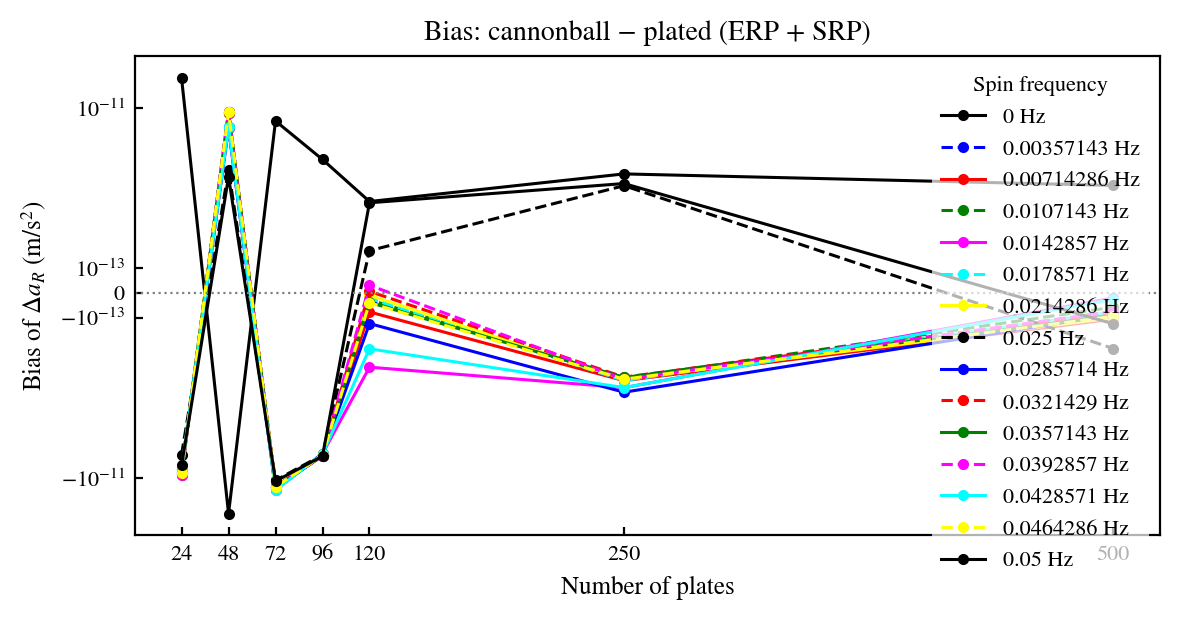

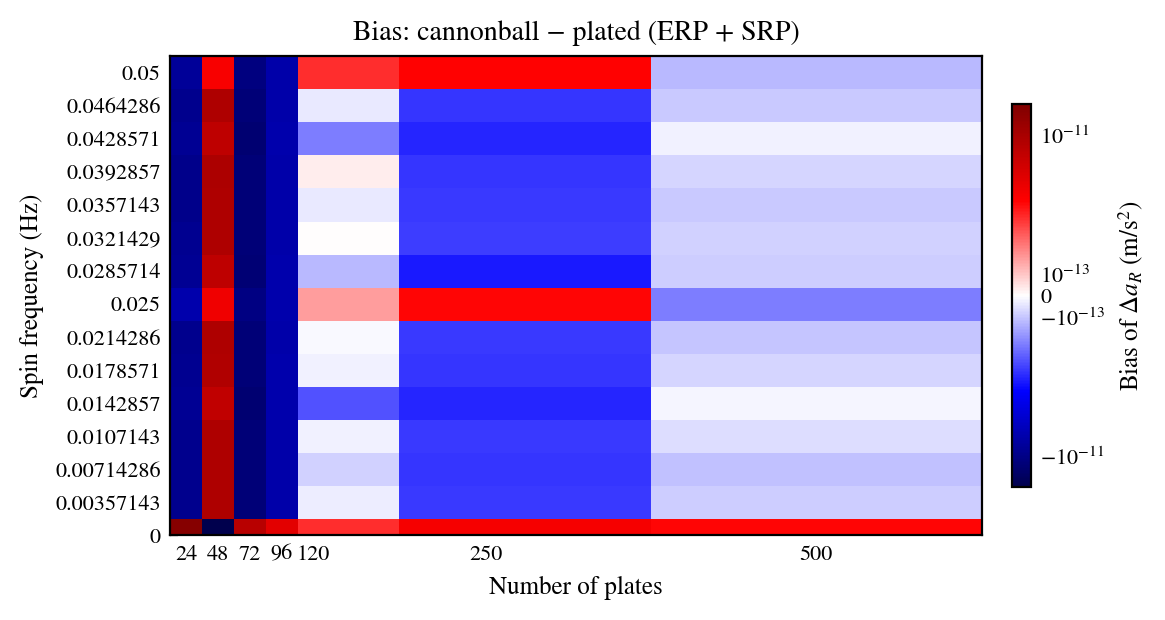

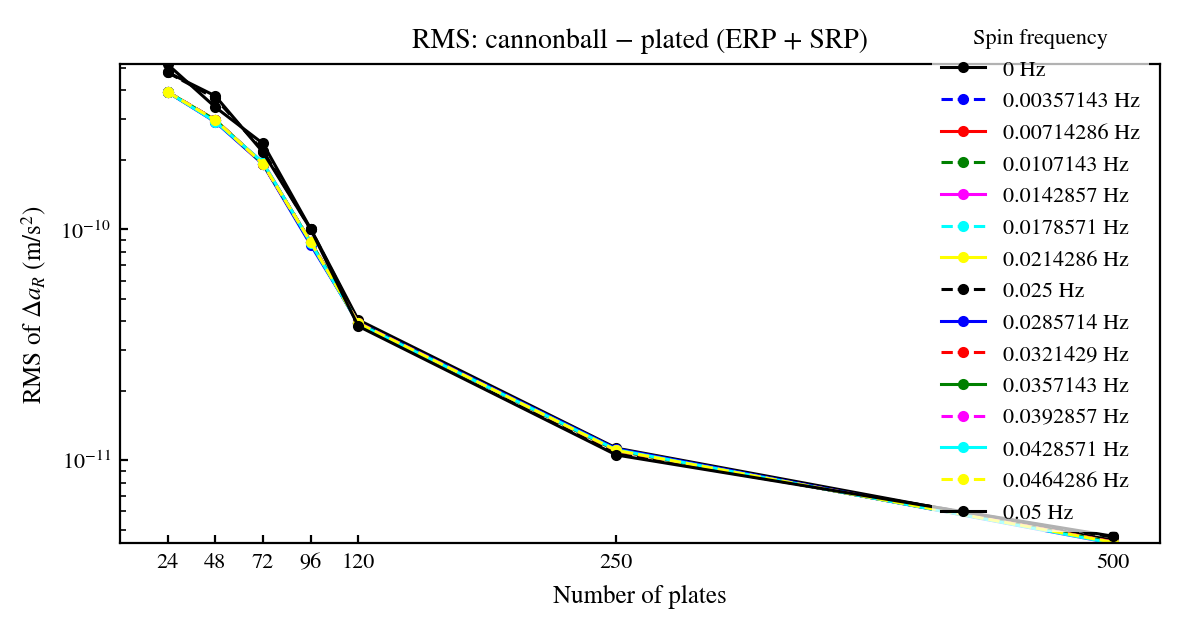

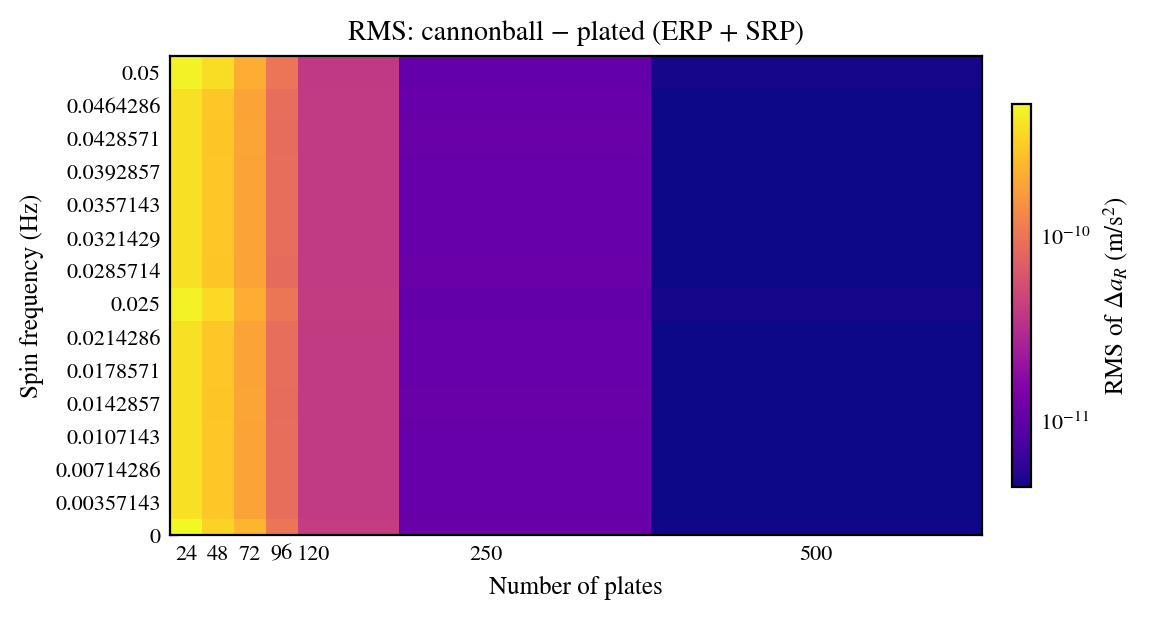

In [4]:
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize, LogNorm, SymLogNorm

USE_LOG_SCALES = True  # False: all linear; True: symlog bias / log RMS (curves and colours).

# Work on sorted copies, preserving the sweep arrays for subsequent analysis.
plate_order = np.argsort(n_faces_array)
frequency_order = np.argsort(spin_f_array)
plate_counts = np.asarray(n_faces_array)[plate_order]
spin_frequencies = np.asarray(spin_f_array)[frequency_order]
expected_shape = (len(spin_f_array), len(n_faces_array))
if np.shape(all_bias) != expected_shape or np.shape(all_rms) != expected_shape:
    raise ValueError("Run the sweep first: bias/RMS shapes must match the frequency and plate arrays.")
bias_by_spin = np.asarray(all_bias)[np.ix_(frequency_order, plate_order)]
rms_by_spin = np.asarray(all_rms)[np.ix_(frequency_order, plate_order)]


def _style_sweep_axes(ax, ylabel):
    ax.set_xlabel('Number of plates', fontsize=Plotter.font_size)
    ax.set_ylabel(ylabel, fontsize=Plotter.font_size)
    ax.set_xticks(plate_counts)
    ax.grid(False)
    ax.tick_params(direction='in', length=3, width=0.8,
                   labelsize=Plotter.font_size_red)
    for spine in ax.spines.values():
        spine.set_linewidth(0.8)


def _sweep_cell_edges(values):
    # Preserve unequal parameter spacing; also support a single sampled value.
    values = np.asarray(values, dtype=float)
    if len(values) == 1:
        half_width = abs(values[0]) / 2 if values[0] else 0.5
        return np.array([max(0, values[0] - half_width), values[0] + half_width])
    midpoints = (values[:-1] + values[1:]) / 2
    return np.r_[max(0, values[0] - (midpoints[0] - values[0])),
                 midpoints, values[-1] + (values[-1] - midpoints[-1])]


# Keep handles available for saving or adjusting individual figures.
sweep_figures = {}
for metric, values in [('Bias', bias_by_spin), ('RMS', rms_by_spin)]:
    # Use the same scale parameters for the curves and the heat map.
    finite_values = values[np.isfinite(values)]
    vmax = np.max(np.abs(finite_values)) if finite_values.size else 0.0
    vmax = vmax if vmax > 0 else np.finfo(float).eps
    plot_values = np.ma.masked_invalid(values)
    if not USE_LOG_SCALES:
        norm = Normalize(vmin=-vmax if metric == 'Bias' else 0, vmax=vmax)
    elif metric == 'Bias':
        # Linear within 1% of the largest absolute bias; logarithmic outside.
        bias_linthresh = max(0.01 * vmax, np.finfo(float).tiny)
        norm = SymLogNorm(linthresh=bias_linthresh, vmin=-vmax, vmax=vmax, base=10)
    else:
        # Zero/nonpositive RMS has no logarithm: leave these entries blank.
        plot_values = np.ma.masked_less_equal(plot_values, 0)
        positive_values = finite_values[finite_values > 0]
        vmin = np.min(positive_values) if positive_values.size else vmax / 10
        if vmin == vmax:
            vmin, vmax = vmin / 10, vmax * 10
        norm = LogNorm(vmin=vmin, vmax=vmax)

    metric_label = rf'{metric} of $\Delta a_R$ (m/s$^2$)'
    fig, ax = plt.subplots(figsize=(1.5 * Plotter.fig_width,
                                    0.8 * Plotter.fig_height), dpi=200)
    for i, spin_f in enumerate(spin_frequencies):
        ax.plot(plate_counts, plot_values[i], label=f'{spin_f:g} Hz',
                color=Plotter.line_colors[i % len(Plotter.line_colors)],
                linestyle=Plotter.linestyles[i % len(Plotter.linestyles)],
                linewidth=Plotter.line_w, marker='o', markersize=3)
    if metric == 'Bias':
        if USE_LOG_SCALES:
            ax.set_yscale('symlog', linthresh=bias_linthresh, base=10)
        ax.axhline(0, color='gray', linestyle=':', linewidth=0.8)
    elif USE_LOG_SCALES:
        ax.set_yscale('log', base=10)
        ax.set_ylim(vmin, vmax)
    else:
        ax.set_ylim(bottom=0)
    _style_sweep_axes(ax, metric_label)
    ax.set_title(f'{metric}: cannonball − plated (ERP + SRP)')
    ax.legend(title='Spin frequency', fontsize=Plotter.font_size_red,
              title_fontsize=Plotter.font_size_red, loc='best')
    fig.tight_layout()
    sweep_figures[f'{metric.lower()}_curves'] = (fig, ax)
    plt.show()

    fig, ax = plt.subplots(figsize=(1.5 * Plotter.fig_width,
                                    0.8 * Plotter.fig_height), dpi=200)
    mesh = ax.pcolormesh(_sweep_cell_edges(plate_counts),
                         _sweep_cell_edges(spin_frequencies),
                         plot_values, shading='flat',
                         cmap='seismic' if metric == 'Bias' else 'plasma',
                         norm=norm)
    _style_sweep_axes(ax, 'Spin frequency (Hz)')
    ax.set_yticks(spin_frequencies)
    ax.set_yticklabels([f'{spin_f:g}' for spin_f in spin_frequencies])
    ax.set_title(f'{metric}: cannonball − plated (ERP + SRP)')
    cbar = fig.colorbar(mesh, ax=ax, shrink=0.8, pad=0.03)
    cbar.set_label(metric_label, fontsize=Plotter.font_size)
    cbar.ax.tick_params(labelsize=Plotter.font_size_red)
    fig.tight_layout()
    sweep_figures[f'{metric.lower()}_heatmap'] = (fig, ax)
    plt.show()

### Why can the residual oscillate around a nonzero mean?

The following are checks suggested by the implementation, rather than a measured attribution of the existing residual:

- **The mesh family changes at the observed threshold.** With `default_golden=False`, the 24, 48, 72, and 96-face cases use symmetric Lebedev-derived vertices. The 120 and 250-face cases fall back to Fibonacci vertices and a convex hull. These are not successive refinements of the same symmetric mesh. Residual directional anisotropy can change abruptly at this transition. Rotation about one axis does not uniformly sample all orientations, so a finite, two-day average need not match the isotropic cannonball response. A direct mesh check gives $\|\sum_p A_p\mathbf{n}_p\mathbf{n}_p^T/\sum_p A_p-I/3\|_F$ of about $10^{-16}$ for the first four meshes, $8.04\times10^{-4}$ at 120 faces, and $9.90\times10^{-5}$ at 250 faces. This second-moment check supports the symmetry change but does not measure the full force error. Compare all counts with `default_golden=True`, then increase the face count and vary the initial orientation to isolate this effect.

- **The cannonball normalization contains fresh Monte Carlo noise.** `get_avg_cross_sectional_area` samples 10,000 random directions on every call, including each frequency for the same mesh. For these convex meshes the exact isotropic mean projected area is `np.sum(areas) / 4`, by [Cauchy's surface-area formula](https://arxiv.org/abs/1109.0595). Equivalently, each face has $\langle\max(0,-\mathbf{s}\cdot\mathbf{n})\rangle=1/4$ over uniform directions. Using `true_avg_area = np.sum(sat_dict['plate_areas']) / 4` would remove this random scale error and make the reference independent of spin frequency. A scale error can shift the time-averaged residual whenever the mean radial flux is nonzero; it need not appear as zero-mean temporal noise.

- **There is an optical-coefficient typo.** The sweep defines `cs_SW = 0.68` but assigns `plate_cs_SW = cd_SW * np.ones(n_faces)`, i.e. 0.20. The coefficients therefore sum to 0.52 instead of 1. Both calculations read this same coefficient array, so this is not by itself proof of a persistent sphere-limit mismatch, but it changes the intended material response and the finite-mesh error. Correct this to `cs_SW * np.ones(n_faces)` before drawing physical conclusions from a new sweep. For the implemented plate law, the isotropic/sphere coefficient is $c_a+c_s+13c_d/9$, matching the expression used in `F_to_a`.

- **Check the actual cadence for spin-phase aliasing.** The saved `SB_R800_21` day-10 and day-11 time arrays have a median cadence of 15 s (up to Julian-date roundoff). Recheck `np.diff(np.concatenate(all_jd)) * 86400` if the selected satellite or data changes, since `sb_tag` overrides the initial query. At 15 s cadence, 0.05, 0.015, and 0.03 Hz advance by 0.75, 0.225, and 0.45 turns per sample, respectively: only 4, 40, and 20 distinct spin phases for constant cadence. Facet symmetry can make the effective coverage still poorer. Shorter sampling intervals, shifted initial phase, and a longer averaging window can distinguish sampling effects from mesh anisotropy.

The existing simulation cells are retained so these figures remain comparable with the current results. For a controlled rerun, first fix the specular coefficient and use the exact area, then compare mesh families and sampling. A finite-plate offset can occur; a nonzero limiting offset as the mesh becomes spherical still calls for checking these effects and the force model. Also, the existing time-series label says ERP, although `net_diff` includes ERP + SRP; the summary figures label that explicitly.